(Poisson-ADR)=
# poisson

We demonstrate here how to solve a simple stationary Poisson equation in the bulk in the form:

\begin{equation*}
- \Delta u + c u = - \nabla\cdot(\nabla u) + cu = f
\end{equation*}

where
- $u$ is the species considered
- $c$ is the reaction coefficient
- $f$ is the right-hand side

The differential symbols $\nabla\cdot, \nabla$ are the usual ones.
We start by creating the mesh we will use.

In [1]:
from cosmos.utils.generate_surface_meshes import generate_circle
from ngsolve import *
from ngsolve.webgui import Draw

mesh, _ = generate_circle()
Draw(mesh)


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

Then we need to decide if our simulation will involve moving boundaries or not.\
For the moment we consider fixed boundaries so we use the class `Simulation` (contrary to `MovingSimulation`) of the `cosmos` package.

This class has to be minimally initialized giving the mesh as input.

We use the maxium `verbosity=2`to have the most amount of information.

In [2]:
from cosmos.solvers.simulation import Simulation

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = Simulation(mesh=mesh, t=t, dt = dt, T = T, verbose = 2)

------------------------------------------------------------
The mesh is a  2D mesh
The number of:
     vertices is:  388
     edges is:  1099
     faces is:  712
     facets is:  1099
     elements is:  712 ( = 0 if hypersurface)
Regions of co-dimension  0 :
 N.  1 region(s) called  default
Regions of co-dimension  1 :
 N.  2 region(s) called  boundary
Regions of co-dimension  2 :
 N.  2 region(s) called  default
------------------------------------------------------------ 



It's time now to create the solver for our equation.  \
This is done using the `ADRSolver` class of the `cosmos` package. \
The solver has then to be added using the mehtod `AddSolver` to the simulation in order to access variables such as the time variables and the mesh.

In [3]:
from cosmos.solvers.adr import ADRSolver
solver = ADRSolver(linear = True)
simulation.AddSolver(solver)

------------------------------------------------------------
This is a general solver for a Advection-Diffusion-Reaction problem.
               It allows to solve surface, bulk and coupled surface-bulk equations.
               It uses conforming H-1 elements of order 1.
Its parameters are
  - linear - with value  True
------------------------------------------------------------ 



At this point we need to prescribe the coefficients of our solver. \
We create a manufactured solution so that later we can use it to perform convergence studies.

In [4]:
from cosmos.solvers.tools import gradient

u_ex = cos(pi*x)*sin(pi*y) # Exact solution
d = 1 # diffusion coefficient
c = 1 +y**2 # reaction coefficient
flux = (- d*gradient(u_ex, Id(2)))
rhs = ( Trace(gradient(flux, Id(2))) + c*u_ex).Compile() # manufactured solution right-hand side

If we are interested in saving the solution, this has to be indicated in advance through the method `SaveSolution`, indicating the folder where to save the files, the name of the files and the number of snapshops we want to save from the simulation, in order to limit the output in case of long simulation

In [5]:
solver.SaveSolution(folderpath = './adr_results/', filename = 'poisson', n_samples = 100)

If we are interested in computing the error between the computed solution and another one we can use the method `ComputeError`, It needs the folder path and the file name as above. Further, it needs the norm that should be used and the coeffients functions themselves. 

In [6]:
solver.ComputeError(ex_sol = u_ex, norm = 'L2', folderpath = './adr_results/', filename = 'poisson_errors')

One can define various types of boundary conditions.

In particular we can prescribe:
- Dirichlet boundary conditions
- Neumann boundary conditions

For both conditions there are two flags, one reserved for the diffusive part and one for the advective part of the equations.

- Dirichlet boundary conditions use `dir_b` for the advective flux and `dir_d` for the diffusive part. In most of the cases, these two coincide.
- Neumann boundary conditions use `neu_b` for the advective flux and `neu_d` for the diffusive flux. These are pretty different and attention should be taken in prescribing these.

Note that when using `neu_b` or `dir_b`, the solver will impose the boundary condition only where the advective field $\vec{b}$ is inward pointing. If one wants to force the condition everywhere, then `Fneu_b` should be used instead.

This information is passed using dictionaries as follows

In [7]:
neu_d = {'boundary': flux}
dir_d = {'boundary': u_ex}

We then proceed to add one species to the solver together with the associated parameters. \
The coeffients can be NgSolve `CoefficientFunctions` or callable functions without an argument that return a `CoefficientFunction`. Also, we specify that the specie is `stationary`, otherwise the software will assume it is not.



In [8]:
## Using Dirichlet boundary conditions
solver.AddSpecie(VorB = VOL,
                rhs = rhs,
                diffusion = d,
                reaction = c,
                u0 = u_ex,
                dir_d = dir_d,
                stationary = True)

# ## Using Neumann boundary conditions
# solver.AddSpecie(VorB = VOL,
#                 rhs = rhs,
#                 diffusion = d,
#                 reaction = c,
#                 u0 = u_ex,
#                 neu_d = neu_d)

We can finally run the simulation and plot the final result, comparing it with the exact solution

In [9]:
simulation.run()
print('\n Computed solution')
solver.draw_solution()
print('\n Exact solution')
Draw(u_ex, mesh)

Initializing...
Initialization successful 
                    N. 1  solvers have been initialized correctly
---------- 
Starting the simulation...


	 Running Simulation...: 100%|█████████████| 10/10 [00:00<00:00, 71.08it/s]

Simulation concluded successfully
----------

 Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…


 Exact solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

The error is now being saved in the separate file we described previously. We can load it and look at the error behaviour.

    Time   specie0
0    0.0  0.008566
1    0.1  0.012109
2    0.2  0.012109
3    0.3  0.012109
4    0.4  0.012109
5    0.5  0.012109
6    0.6  0.012109
7    0.7  0.012109
8    0.8  0.012109
9    0.9  0.012109
10   1.0  0.012109


<function matplotlib.pyplot.show(close=None, block=None)>

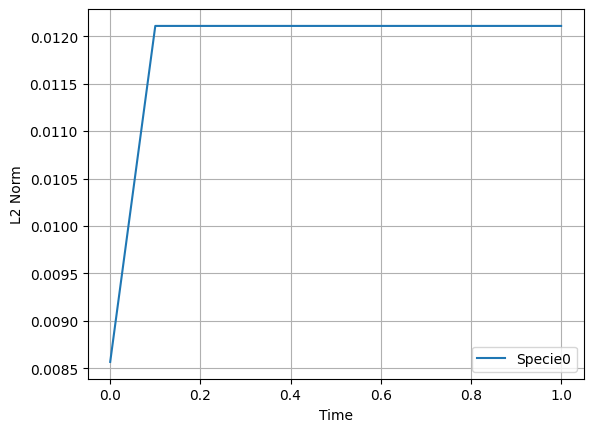

In [10]:

import pandas as pd

file_path = "./adr_results/poisson_errors"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

import matplotlib.pyplot as plt
plt.plot(df['Time'], df['specie0'], label = 'Specie0')
plt.xlabel('Time')
plt.ylabel('L2 Norm')
plt.grid()
plt.legend()
plt.show